# FDDES Project 2026

This is the main working file of the project. Here, we review the computations done in "fdd/...". This acts as the main pipeline (imports and runs preprocessing, fd-methods, evaluation, etc).   

## Faulty cases - Ground truth
We know the start and end times of the faults in the different cases which serves as a ground truth to compare the results with.

In [1]:
SEfc1_1 = [1566, 5181] # Fault start and end for FaultyCase1 set 1.1
SEfc1_2 = [657, 3777]
SEfc1_3 = [691, 3691]

SEfc2_1 = [2244, 6616]
SEfc2_2 = [476, 2656]
SEfc2_3 = [331, 2467]

SEfc3_1 = [1136, 8352]
SEfc3_2 = [333, 5871]
SEfc3_3 = [596, 9566]

SEfc4_1 = [953, 6294]
SEfc4_2 = [851, 3851]
SEfc4_3 = [241, 3241]

SEfc5_1 = [686, 1172, 1772, 2253] # Fault start and end for FaultyCase5 set 5.1 with two faults
SEfc5_2 = [1633, 2955, 7031, 7553, 8057, 10608] # with three faults

SEfc6_1 = [1723, 2800]
SEfc6_2 = [1037, 4830]

# cases, sets, and their corresponding fault windows
se_windows = {
    "FaultyCase1": {"Set1_1": SEfc1_1, "Set1_2": SEfc1_2, "Set1_3": SEfc1_3},
    "FaultyCase2": {"Set2_1": SEfc2_1, "Set2_2": SEfc2_2, "Set2_3": SEfc2_3},
    "FaultyCase3": {"Set3_1": SEfc3_1, "Set3_2": SEfc3_2, "Set3_3": SEfc3_3},
    "FaultyCase4": {"Set4_1": SEfc4_1, "Set4_2": SEfc4_2, "Set4_3": SEfc4_3},
    "FaultyCase5": {"Set5_1": SEfc5_1, "Set5_2": SEfc5_2},
    "FaultyCase6": {"Set6_1": SEfc6_1, "Set6_2": SEfc6_2}
}

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fdd.dataloader import DataLoader
from fdd.dataset import TimeSeriesDataset
from fdd.preprocessor import StandardPreprocessor
from fdd.pca import pca_fit, pca_transform
from fdd.dpca import dpca_fit, dpca_transform, dpca_prepare_matrix
from fdd.statistics import q_statistic, t2_statistic
from fdd.fda import FDAModel

In [3]:
def normalize_fault_windows(window):
    """Convert [start, end, start, end, ...] to [(start, end), ...]."""
    if len(window) % 2 != 0:
        raise ValueError(f"Fault window must contain start/end pairs. Got: {window}")
    return [(int(window[i]), int(window[i + 1])) for i in range(0, len(window), 2)]


def is_in_fault_window(samples, windows):
    """Boolean mask for whether each sample index lies inside any fault window."""
    samples = np.asarray(samples)
    mask = np.zeros(len(samples), dtype=bool)
    for start, end in normalize_fault_windows(windows):
        mask |= (samples >= start) & (samples <= end)
    return mask


def first_detection_delay(alarm_mask, windows, sample_index=None):
    """First alarm delay relative to the first fault start. Uses sample index, not row position."""
    alarm_mask = np.asarray(alarm_mask, dtype=bool)
    if sample_index is None:
        sample_index = np.arange(len(alarm_mask))
    else:
        sample_index = np.asarray(sample_index)

    first_fault_start = normalize_fault_windows(windows)[0][0]
    alarms_after_start = sample_index[alarm_mask & (sample_index >= first_fault_start)]
    if len(alarms_after_start) == 0:
        return np.nan
    return int(alarms_after_start[0] - first_fault_start)


def count_false_alarms(alarm_mask, windows, sample_index=None):
    """Counts alarms outside all labelled fault windows."""
    alarm_mask = np.asarray(alarm_mask, dtype=bool)
    if sample_index is None:
        sample_index = np.arange(len(alarm_mask))
    else:
        sample_index = np.asarray(sample_index)
    fault_mask = is_in_fault_window(sample_index, windows)
    return int(np.sum(alarm_mask & ~fault_mask))


def add_fault_spans(ax, windows, **kwargs):
    """Draw all fault windows on a matplotlib axis."""
    defaults = {"alpha": 0.2}
    defaults.update(kwargs)
    for start, end in normalize_fault_windows(windows):
        ax.axvspan(start, end, **defaults)
        ax.axvline(start, linestyle="--")


## Data loading

In [14]:
from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor

loader = DataLoader()

# Training data 
trainsets = loader.load("Training")

# Faulty cases (test data)
FC1sets = loader.load("FaultyCase1")
FC2sets = loader.load("FaultyCase2")
FC3sets = loader.load("FaultyCase3")
FC4sets = loader.load("FaultyCase4")
FC5sets = loader.load("FaultyCase5")
FC6sets = loader.load("FaultyCase6")
fc_sets = [FC1sets, FC2sets, FC3sets, FC4sets, FC5sets, FC6sets]

In [15]:
fc_sets_raw = [FC1sets, FC2sets, FC3sets, FC4sets, FC5sets, FC6sets] # Til FDA

# Training

## Preprocessing

In [6]:

# Centering and scaling
# Fit preprocessing ONLY on healthy training data. Do not fit preprocessing on fault/test data.

train_set_1 = trainsets["T1"] # others are "T2" and "T3"
print(train_set_1.summary())

# Keep remove_outliers=False for FDD evaluation so the time index stays aligned with fault windows.
preprocessor = StandardPreprocessor(with_standardization=True, remove_outliers=False)
X_processed = preprocessor.fit_transform(train_set_1)

X = X_processed.sensors
X_processed.sensors.head()


TimeSeriesDataset(name=T1, n_samples=10372, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,-1.437195,-1.371980,-0.816336,-0.559184,-0.633159,-1.179499,-0.638294,-1.226225,-1.096560,-0.547632,...,0.541646,0.450026,1.521277,1.980402,0.651681,1.018815,-1.399210,-1.287813,-1.114830,-1.359768
1,-1.432961,-1.367098,-0.801770,-0.541074,-0.609245,-1.172216,-0.617034,-1.195433,-1.096552,-0.547634,...,0.541434,0.449249,1.510648,1.974524,0.774889,1.013263,-1.402489,-1.295797,-1.114843,-1.595380
2,-1.428350,-1.368818,-0.749364,-0.522919,-0.585314,-1.172762,-0.521361,-1.184190,-1.096545,-0.547635,...,0.541222,0.448277,1.500020,1.968650,0.774889,1.007713,-1.405764,-1.303780,-1.114856,-1.006349
3,-1.423731,-1.363055,-0.769740,-0.504814,-0.561391,-1.173308,-0.726880,-1.184610,-1.096537,-0.547637,...,0.541010,0.447500,1.489392,1.962775,0.774889,1.002156,-1.409040,-1.308472,-1.114870,-1.438305
4,-1.419120,-1.351676,-0.766810,-0.514497,-0.537469,-1.168822,-0.755228,-1.199208,-1.096529,-0.547638,...,0.540798,0.446528,1.478761,1.956900,0.779823,0.996604,-1.412319,-1.309872,-1.114883,-2.341485


## Shewhart

In [16]:
mean = X.mean()
std = X.std()
shewhart_threshold = mean + 3 * std # Shewhart control limit (3-sigma rule)

## PCA

Original X shape: (10372, 23)
PCA-transformed Z shape: (10372, 2)
Explained variance ratio: [0.47201557 0.20494557]
Cumulative explained variance: [0.47201557 0.67696115]
Total explained variance: 0.6769611467392285
         Z1        Z2
0  3.158374 -2.554867
1  3.215427 -2.546264
2  3.116147 -2.503575
3  3.221971 -2.517498
4  3.239647 -2.545264


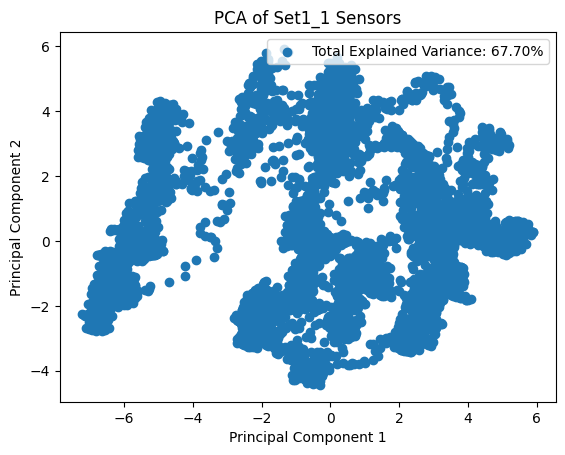

In [17]:
from fdd.pca import pca_fit
from fdd.pca import pca_transform

pca_model = pca_fit(X, n_components=2)
Z_pca = pca_transform(X, pca_model)
evr_pca = pca_model["explained_variance_ratio"]

print('Original X shape:', X.shape)
print('PCA-transformed Z shape:', Z_pca.shape)
print('Explained variance ratio:', evr_pca.values)
print('Cumulative explained variance:', evr_pca.cumsum().values)
print('Total explained variance:', evr_pca.sum())
print(Z_pca.head())

plt.scatter(Z_pca["Z1"], Z_pca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Set1_1 Sensors")
plt.legend([f'Total Explained Variance: {evr_pca.sum()*100:.2f}%'])          
plt.show()

The total explained variance is only 47% meaning only 47% of the data can be explained with these two principal components. Therefore a 2D PCA is mainly used for visualization and not as a complete representation. 

Since X has been reduced down to 2 "features" in Z, that makes us able to plot them.

### Q and T2 statistics for PCA

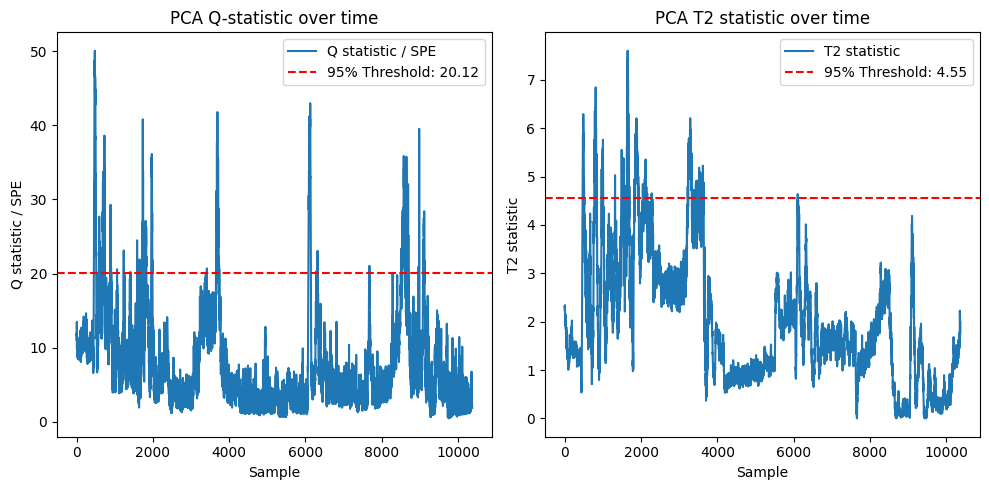

In [18]:

# Q-statistic
from fdd.statistics import q_statistic
q_train_pca = q_statistic(X, Z_pca, pca_model)
threshold_q_pca = np.percentile(q_train_pca, 95)

# Hotteling's T2 statistic
from fdd.statistics import t2_statistic
t2_train_pca = t2_statistic(Z_pca, pca_model)
threshold_t2_pca = np.percentile(t2_train_pca, 95)

# Plot Q-statistic and T2 statistic over time with thresholds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q_train_pca, label='Q statistic / SPE')
plt.axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
plt.xlabel("Sample")
plt.ylabel("Q statistic / SPE")
plt.title("PCA Q-statistic over time")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t2_train_pca, label='T2 statistic')
plt.axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
plt.xlabel("Sample")
plt.ylabel("T2 statistic")
plt.title("PCA T2 statistic over time")
plt.legend()
plt.tight_layout()
plt.show()

When finding the thresholds during training, a 95% threshold means that you can expect about 5% false alarms. 

## DPCA transform

Original X shape: (10372, 23)
DPCA-transformed Z shape: (10367, 2)
Explained variance ratio: [0.47121075 0.20439447]
Cumulative explained variance: [0.47121075 0.67560522]
Total explained variance: 0.6756052246948808
         Z1        Z2
5  7.724041 -6.202630
6  7.600972 -6.184793
7  7.470835 -6.194895
8  7.346702 -6.239781
9  7.107691 -6.272626


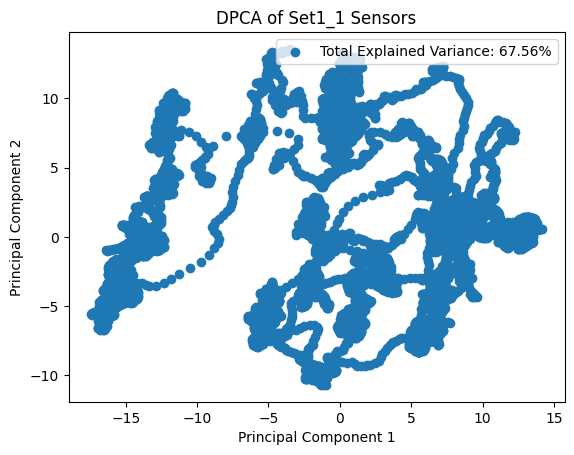

In [19]:
from fdd.dpca import dpca_fit
from fdd.dpca import dpca_transform
from fdd.dpca import dpca_prepare_matrix

dpca_model = dpca_fit(X, n_components=2, time_lags=5)
evr_dpca = dpca_model["explained_variance_ratio"]
Z_dpca = dpca_transform(X, dpca_model)

print('Original X shape:', X.shape)
print('DPCA-transformed Z shape:', Z_dpca.shape)
print('Explained variance ratio:', evr_dpca.values)
print('Cumulative explained variance:', evr_dpca.cumsum().values)
print('Total explained variance:', evr_dpca.sum())
print(Z_dpca.head())

plt.scatter(Z_dpca["Z1"], Z_dpca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DPCA of Set1_1 Sensors")
plt.legend([f'Total Explained Variance: {evr_dpca.sum()*100:.2f}%'])          
plt.show()

### Q and T2 statistic for DPCA

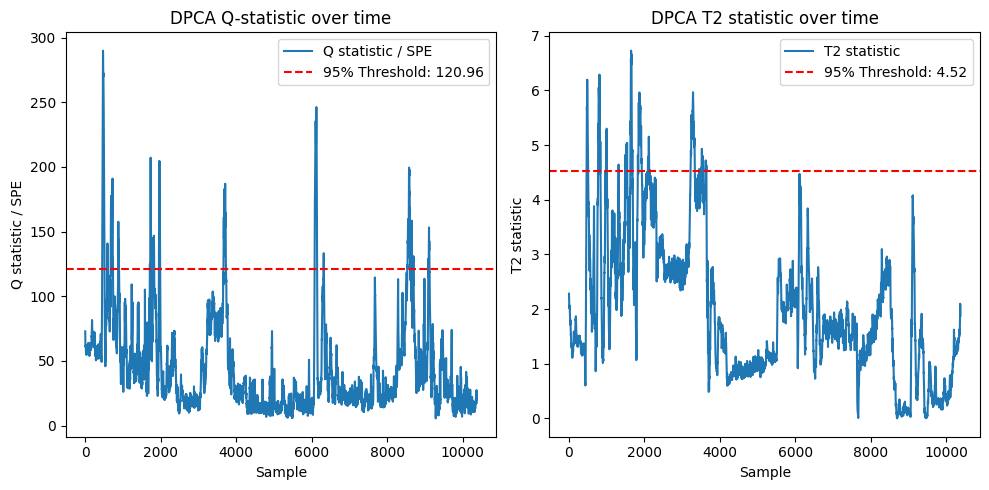

In [20]:
# Q-statistic
from fdd.statistics import q_statistic

X_lagged = dpca_prepare_matrix(X, dpca_model)

q_values_dpca = q_statistic(X_lagged, Z_dpca, dpca_model["pca_model"]) # Remember to use lagged X for DPCA
threshold_q_dpca = np.percentile(q_values_dpca, 95)

# Hotteling's T2 statistic
from fdd.statistics import t2_statistic
t2_values_dpca = t2_statistic(Z_dpca, dpca_model["pca_model"])
threshold_t2_dpca = np.percentile(t2_values_dpca, 95)

# Plot Q-statistic and T2 statistic over time with thresholds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q_values_dpca, label='Q statistic / SPE')
plt.axhline(y=threshold_q_dpca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_dpca:.2f}')
plt.xlabel("Sample")
plt.ylabel("Q statistic / SPE")
plt.title("DPCA Q-statistic over time")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t2_values_dpca, label='T2 statistic')
plt.axhline(y=threshold_t2_dpca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_dpca:.2f}')
plt.xlabel("Sample")
plt.ylabel("T2 statistic")
plt.title("DPCA T2 statistic over time")
plt.legend()
plt.tight_layout()
plt.show()

## FDA Training

In [23]:

# FDA training data.
# Train FDA on labelled FaultyCase1 only, and treat FaultyCase2-6 as held-out fault cases below.
# This is a simple binary diagnosis setup: class 0 = healthy region, class 1 = fault region.

X_train_list = []
y_train_list = []

fda_train_case = "FaultyCase1"

for name, dataset in FC1sets.items():
    df = dataset.sensors.copy().interpolate().ffill().bfill()
    windows = normalize_fault_windows(se_windows[fda_train_case][name])

    sample_index = np.arange(len(df))
    fault_mask = is_in_fault_window(sample_index, se_windows[fda_train_case][name])

    healthy = df.loc[~fault_mask]
    faulty = df.loc[fault_mask]

    X_train_list.append(healthy)
    y_train_list.append(np.zeros(len(healthy), dtype=int))

    X_train_list.append(faulty)
    y_train_list.append(np.ones(len(faulty), dtype=int))

X_fda = pd.concat(X_train_list, axis=0, ignore_index=True)
y_fda = np.concatenate(y_train_list)

fda_training_dataset = TimeSeriesDataset(
    name="FDA_training_data_FaultyCase1",
    sensors=X_fda,
    metadata={"description": "Pooled healthy/fault labelled data from FaultyCase1 only"},
)

fda_model = FDAModel()
fda_model.fit(fda_training_dataset, y_fda)


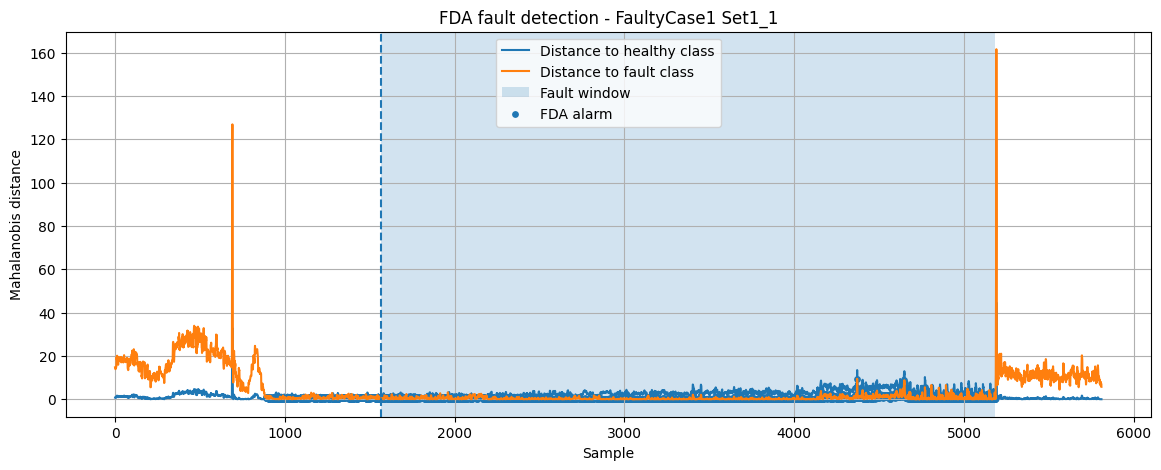

In [24]:

case_name = "FaultyCase1"
set_name = "Set1_1"
windows = se_windows[case_name][set_name]

dataset = FC1sets[set_name]
pred, distances, d_healthy, d_fault, margin = fda_model.predict(dataset)

plt.figure(figsize=(14, 5))
plt.plot(d_healthy, label="Distance to healthy class")
plt.plot(d_fault, label="Distance to fault class")
add_fault_spans(plt.gca(), windows, label="Fault window")

alarm_idx = np.where(pred == 1)[0]
plt.scatter(alarm_idx, d_fault[alarm_idx], s=15, label="FDA alarm")

plt.title(f"FDA fault detection - {case_name} {set_name}")
plt.xlabel("Sample")
plt.ylabel("Mahalanobis distance")
plt.legend()
plt.grid(True)
plt.show()


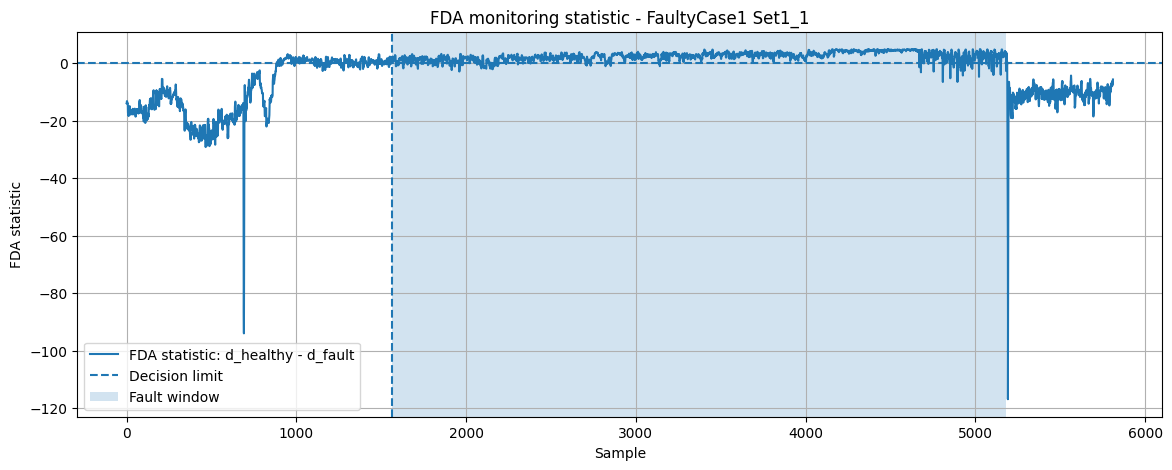

In [25]:

fda_stat = d_healthy - d_fault

plt.figure(figsize=(14, 5))
plt.plot(fda_stat, label="FDA statistic: d_healthy - d_fault")
plt.axhline(0, linestyle="--", label="Decision limit")
add_fault_spans(plt.gca(), windows, label="Fault window")

plt.title(f"FDA monitoring statistic - {case_name} {set_name}")
plt.xlabel("Sample")
plt.ylabel("FDA statistic")
plt.legend()
plt.grid(True)
plt.show()


# Testing - Faulty cases

## Preprocessing of FC data

In [26]:

# Process all faulty/test sets with the SAME preprocessor fitted on healthy training data.
# This avoids train/test leakage.

fc_sets_processed = [
    {set_name: preprocessor.transform(dataset) for set_name, dataset in case_sets.items()}
    for case_sets in fc_sets_raw
]

# Use this variable in all Shewhart/PCA/DPCA test loops below.
fc_sets = fc_sets_processed

X_test_processed = fc_sets[0]["Set1_1"]
X_test_processed.sensors.head()


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,-1.275804,-1.220030,-0.873134,-0.559602,-0.420037,-1.015765,-0.921769,-1.270314,-1.100848,-0.547032,...,0.624238,-3.233343,2.950422,5.065796,6.809990,-17.409198,-1.270037,-1.089388,-1.111256,-1.006349
1,-1.318733,-1.260415,-0.902263,-0.623141,-0.349653,-1.052221,-0.723337,-1.271279,-1.100836,-0.547034,...,0.624239,-3.244225,2.945731,5.065464,6.820944,-17.410898,-1.266652,-1.088334,-1.111212,-1.713185
2,-1.351124,-1.268854,-0.804688,-0.647236,-0.279274,-1.081472,-0.811923,-1.272159,-1.100824,-0.547035,...,0.624239,-3.255204,2.941040,5.065147,6.831913,-17.412598,-1.261251,-1.087279,-1.111167,-2.478925
3,-1.359398,-1.279953,-0.664876,-0.541497,-0.208902,-1.108322,-0.960747,-1.272453,-1.100812,-0.547037,...,0.624240,-3.265989,2.936350,5.064830,6.842870,-17.414299,-1.255845,-1.086225,-1.111122,-2.498560
4,-1.374539,-1.309463,-0.673619,-0.392433,-0.158428,-1.135171,-0.808379,-1.272579,-1.100800,-0.547039,...,0.624241,-3.276773,2.931661,5.064497,6.853839,-17.415999,-1.250445,-1.085170,-1.111078,-0.751102


## Shewhart testing

In [27]:
Shew_X_FC1_1 = fc_sets[0]["Set1_1"].sensors
shew_anomalies_fc1_1 = (Shew_X_FC1_1 > shewhart_threshold).sum()
print(shew_anomalies_fc1_1)
print(f"Total number of anomalies detected by Shewhart in FC1 Set 1.1: {shew_anomalies_fc1_1.sum()}")

Air_Delivery_P         1800
P_Bottom_Riser          257
P_Top_Riser             104
P_Top_Separator          90
P_3Phase_Separator      223
Diff_P_Riser            255
Diff_P_VC404             77
Air_In_Flow               3
Water_In_Flow             0
Flow_Top_Riser         1040
Level_Top_Sep             0
Flow_Top_Sep_Out         80
Density_Top_Riser       162
Density_Top_Sep_Out       0
Density_Water_In          0
Temp_Top_Riser         5758
Temp_Top_Sep_Out       5811
Temp_Water_In          5811
Level_3Phase_Sep          0
Pos_VC501                19
Pos_VC302                 0
Pos_VC101                 0
Pump_Current_PO1          0
dtype: int64
Total number of anomalies detected by Shewhart in FC1 Set 1.1: 21490


In [28]:

# Shewhart evaluation on all faulty/test sets.
# Uses all fault windows, including multi-window FC5 cases.

shew_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, dataset in case_sets.items():
        X_fault = dataset.sensors
        windows = se_windows[case_name][set_name]

        shew_alarm_mask = (X_fault > shewhart_threshold).any(axis=1).to_numpy()
        sample_index = X_fault.index.to_numpy()

        shew_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),
            "Detection delay Shewhart": first_detection_delay(shew_alarm_mask, windows, sample_index),
            "Shewhart alarm samples": int(np.sum(shew_alarm_mask)),
            "Shewhart cell anomalies": int((X_fault > shewhart_threshold).to_numpy().sum()),
            "Shewhart false alarms": count_false_alarms(shew_alarm_mask, windows, sample_index),
        })

shew_results_df = pd.DataFrame(shew_results)
print("Shewhart Results:")
shew_results_df


Shewhart Results:


,Case,Set,Samples,Detection delay Shewhart,Shewhart alarm samples,Shewhart cell anomalies,Shewhart false alarms
0,FaultyCase1,Set1_1,5811,0,5811,21490,2195
1,FaultyCase1,Set1_2,4467,0,4467,17775,1346
2,FaultyCase1,Set1_3,4321,0,4321,15871,1320
3,FaultyCase2,Set2_1,9192,0,8982,25964,4609
4,FaultyCase2,Set2_2,3496,0,3496,10602,1315
5,FaultyCase2,Set2_3,3421,0,3421,12100,1284
6,FaultyCase3,Set3_1,9090,0,9090,56675,1873
7,FaultyCase3,Set3_2,6272,0,6272,42062,733
8,FaultyCase3,Set3_3,10764,0,10764,69264,1793
9,FaultyCase4,Set4_1,7208,0,7208,31849,1866


## PCA testing

PCA on Set1_1: Q-statistic detection delay: 0 samples
PCA on Set1_1: T2 statistic detection delay: 0 samples
PCA on Set1_1: Number of Q-statistic alarm samples: 5811 of 5811 samples
PCA on Set1_1: Number of T2 statistic alarm samples: 4472 of 5811 samples


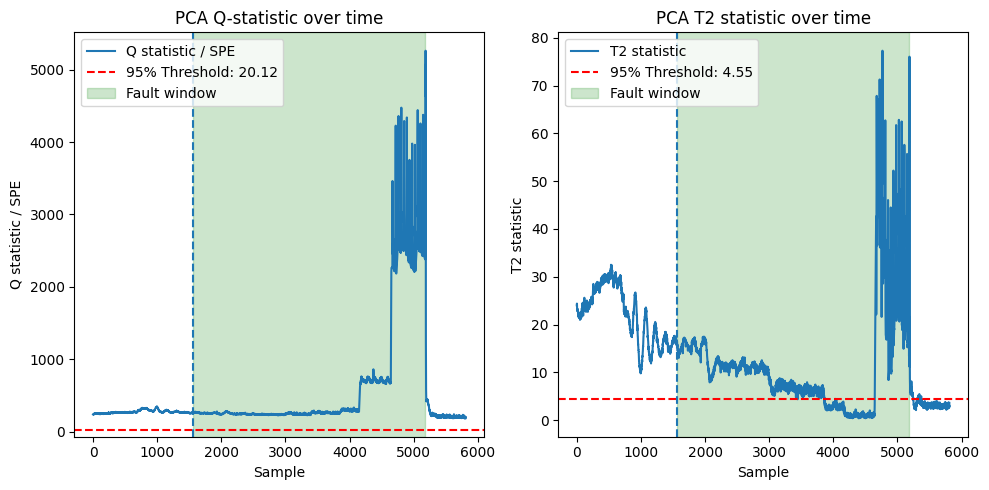

In [29]:

# A single PCA test on FaultyCase1 Set1_1
case_name = "FaultyCase1"
set_name = "Set1_1"
windows = se_windows[case_name][set_name]

PCA_X_FC1_1 = fc_sets[0][set_name].sensors
PCA_Z_FC1_1 = pca_transform(PCA_X_FC1_1, pca_model)
PCA_q_FC1_1 = q_statistic(PCA_X_FC1_1, PCA_Z_FC1_1, pca_model)
PCA_t2_FC1_1 = t2_statistic(PCA_Z_FC1_1, pca_model)

q_alarm_mask = (PCA_q_FC1_1 > threshold_q_pca).to_numpy()
t2_alarm_mask = (PCA_t2_FC1_1 > threshold_t2_pca).to_numpy()

print(f"PCA on {set_name}: Q-statistic detection delay: {first_detection_delay(q_alarm_mask, windows, PCA_q_FC1_1.index)} samples")
print(f"PCA on {set_name}: T2 statistic detection delay: {first_detection_delay(t2_alarm_mask, windows, PCA_t2_FC1_1.index)} samples")
print(f"PCA on {set_name}: Number of Q-statistic alarm samples: {int(q_alarm_mask.sum())} of {len(PCA_q_FC1_1)} samples")
print(f"PCA on {set_name}: Number of T2 statistic alarm samples: {int(t2_alarm_mask.sum())} of {len(PCA_t2_FC1_1)} samples")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(PCA_q_FC1_1, label='Q statistic / SPE')
axes[0].axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
add_fault_spans(axes[0], windows, color='g', label='Fault window')
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("PCA Q-statistic over time")
axes[0].legend()

axes[1].plot(PCA_t2_FC1_1, label='T2 statistic')
axes[1].axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
add_fault_spans(axes[1], windows, color='g', label='Fault window')
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("PCA T2 statistic over time")
axes[1].legend()
plt.tight_layout()
plt.show()


In [30]:

# PCA evaluation on all faulty/test sets.
# Uses all fault windows and preserves sample index.

pca_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, dataset in case_sets.items():
        X_fault = dataset.sensors
        windows = se_windows[case_name][set_name]

        Z_fault = pca_transform(X_fault, pca_model)
        q_fault = q_statistic(X_fault, Z_fault, pca_model)
        t2_fault = t2_statistic(Z_fault, pca_model)

        q_alarm_mask = (q_fault > threshold_q_pca).to_numpy()
        t2_alarm_mask = (t2_fault > threshold_t2_pca).to_numpy()

        pca_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),
            "Detection delay Q": first_detection_delay(q_alarm_mask, windows, q_fault.index),
            "Detection delay T2": first_detection_delay(t2_alarm_mask, windows, t2_fault.index),
            "Q alarm samples": int(np.sum(q_alarm_mask)),
            "T2 alarm samples": int(np.sum(t2_alarm_mask)),
            "Q false alarms": count_false_alarms(q_alarm_mask, windows, q_fault.index),
            "T2 false alarms": count_false_alarms(t2_alarm_mask, windows, t2_fault.index),
        })

pca_results_df = pd.DataFrame(pca_results)
print("PCA Results:")
pca_results_df


PCA Results:


,Case,Set,Samples,Detection delay Q,Detection delay T2,Q alarm samples,T2 alarm samples,Q false alarms,T2 false alarms
0,FaultyCase1,Set1_1,5811,0,0,5811,4472,2195,1643
1,FaultyCase1,Set1_2,4467,0,2406,4467,833,1346,118
2,FaultyCase1,Set1_3,4321,0,279,4321,1459,1320,398
3,FaultyCase2,Set2_1,9192,0,288,9192,6236,4819,3599
4,FaultyCase2,Set2_2,3496,0,0,3496,3489,1315,1308
5,FaultyCase2,Set2_3,3421,0,1505,3421,792,1284,268
6,FaultyCase3,Set3_1,9090,0,0,9090,8719,1873,1863
7,FaultyCase3,Set3_2,6272,0,662,6272,1794,733,147
8,FaultyCase3,Set3_3,10764,0,0,10764,10666,1793,1792
9,FaultyCase4,Set4_1,7208,0,0,7208,6757,1866,1866


In [31]:
# # This plots Q and T2 statistics for all sets in all cases

# for case_name, case_sets in zip(se_windows.keys(), fc_sets):
#     for set_name, fault_window in zip(case_sets.keys(), se_windows[case_name]):
#         X_fault = case_sets[set_name].sensors
#         Z_fault = pca_transform(X_fault, pca_model)
#         q_fault = q_statistic(X_fault, Z_fault)
#         t2_fault = t2_statistic(Z_fault)

#         n_q_anomalies = np.sum(q_fault > threshold_q_pca)
#         n_t2_anomalies = np.sum(t2_fault > threshold_t2_pca)

#         print(f"PCA on {case_name} {set_name}: Number of Q-statistic anomalies: {n_q_anomalies} of {len(X_fault)} samples")
#         print(f"PCA on {case_name} {set_name}: Number of T2 statistic anomalies: {n_t2_anomalies} of {len(X_fault)} samples")

#         plt.figure(figsize=(10, 5))
#         plt.subplot(1, 2, 1)
#         plt.plot(q_fault, label='Q statistic / SPE')
#         plt.axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
#         plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
#         plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
#         plt.xlabel("Sample")
#         plt.ylabel("Q statistic / SPE")
#         plt.title(f"PCA Q-statistic over time - {case_name} {set_name}")
#         plt.legend()

#         plt.subplot(1, 2, 2)
#         plt.plot(t2_fault, label='T2 statistic')
#         plt.axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
#         plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
#         plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
#         plt.xlabel("Sample")
#         plt.ylabel("T2 statistic")
#         plt.title(f"PCA T2 statistic over time - {case_name} {set_name}")
#         plt.legend()
#         plt.tight_layout()
#         plt.show()

## DPCA testing

DPCA on Set1_1: Q-statistic detection delay: 0 samples
DPCA on Set1_1: T2 statistic detection delay: 0 samples
DPCA on Set1_1: Number of Q-statistic alarm samples: 5806 of 5806 samples
DPCA on Set1_1: Number of T2 statistic alarm samples: 4470 of 5806 samples


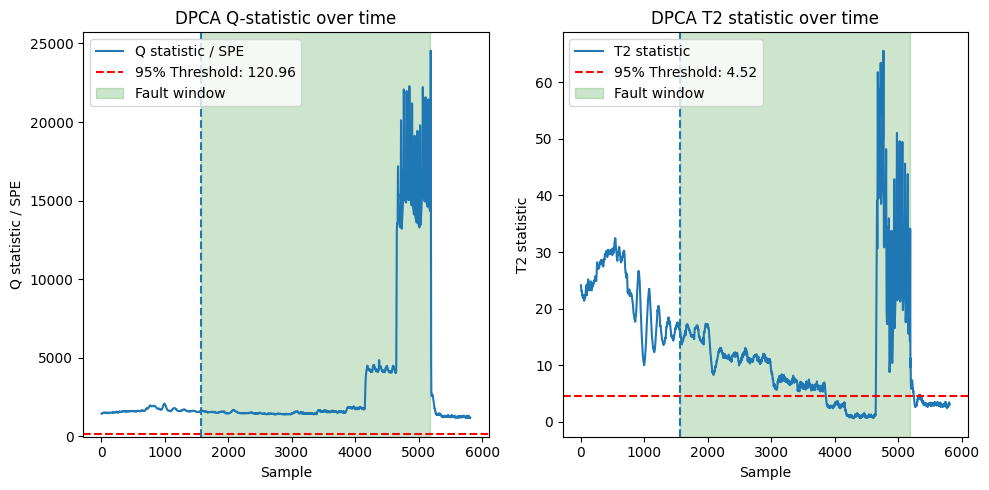

In [32]:

# A single DPCA test on FaultyCase1 Set1_1
case_name = "FaultyCase1"
set_name = "Set1_1"
windows = se_windows[case_name][set_name]

DPCA_X_FC1_1 = fc_sets[0][set_name].sensors
DPCA_X_FC1_1_lagged = dpca_prepare_matrix(DPCA_X_FC1_1, dpca_model)
DPCA_Z_FC1_1 = dpca_transform(DPCA_X_FC1_1, dpca_model)
DPCA_q_FC1_1 = q_statistic(DPCA_X_FC1_1_lagged, DPCA_Z_FC1_1, dpca_model["pca_model"])
DPCA_t2_FC1_1 = t2_statistic(DPCA_Z_FC1_1, dpca_model["pca_model"])

q_alarm_mask = (DPCA_q_FC1_1 > threshold_q_dpca).to_numpy()
t2_alarm_mask = (DPCA_t2_FC1_1 > threshold_t2_dpca).to_numpy()

print(f"DPCA on {set_name}: Q-statistic detection delay: {first_detection_delay(q_alarm_mask, windows, DPCA_q_FC1_1.index)} samples")
print(f"DPCA on {set_name}: T2 statistic detection delay: {first_detection_delay(t2_alarm_mask, windows, DPCA_t2_FC1_1.index)} samples")
print(f"DPCA on {set_name}: Number of Q-statistic alarm samples: {int(q_alarm_mask.sum())} of {len(DPCA_q_FC1_1)} samples")
print(f"DPCA on {set_name}: Number of T2 statistic alarm samples: {int(t2_alarm_mask.sum())} of {len(DPCA_t2_FC1_1)} samples")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(DPCA_q_FC1_1, label='Q statistic / SPE')
axes[0].axhline(y=threshold_q_dpca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_dpca:.2f}')
add_fault_spans(axes[0], windows, color='g', label='Fault window')
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Q statistic / SPE")
axes[0].set_title("DPCA Q-statistic over time")
axes[0].legend()

axes[1].plot(DPCA_t2_FC1_1, label='T2 statistic')
axes[1].axhline(y=threshold_t2_dpca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_dpca:.2f}')
add_fault_spans(axes[1], windows, color='g', label='Fault window')
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("T2 statistic")
axes[1].set_title("DPCA T2 statistic over time")
axes[1].legend()
plt.tight_layout()
plt.show()


In [33]:

# DPCA evaluation on all faulty/test sets.
# DPCA statistics start at original sample index = time_lags, so use the Series index for delays and false alarms.

dpca_results = []

for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, dataset in case_sets.items():
        X_fault = dataset.sensors
        windows = se_windows[case_name][set_name]

        X_fault_lagged = dpca_prepare_matrix(X_fault, dpca_model)
        Z_fault = dpca_transform(X_fault, dpca_model)
        q_fault = q_statistic(X_fault_lagged, Z_fault, dpca_model["pca_model"])
        t2_fault = t2_statistic(Z_fault, dpca_model["pca_model"])

        q_alarm_mask = (q_fault > threshold_q_dpca).to_numpy()
        t2_alarm_mask = (t2_fault > threshold_t2_dpca).to_numpy()

        dpca_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(X_fault),
            "Detection delay Q": first_detection_delay(q_alarm_mask, windows, q_fault.index),
            "Detection delay T2": first_detection_delay(t2_alarm_mask, windows, t2_fault.index),
            "Q alarm samples": int(np.sum(q_alarm_mask)),
            "T2 alarm samples": int(np.sum(t2_alarm_mask)),
            "Q false alarms": count_false_alarms(q_alarm_mask, windows, q_fault.index),
            "T2 false alarms": count_false_alarms(t2_alarm_mask, windows, t2_fault.index),
        })

dpca_results_df = pd.DataFrame(dpca_results)
print("DPCA Results:")
dpca_results_df


DPCA Results:


,Case,Set,Samples,Detection delay Q,Detection delay T2,Q alarm samples,T2 alarm samples,Q false alarms,T2 false alarms
0,FaultyCase1,Set1_1,5811,0,0.0,5806,4470,2190,1642
1,FaultyCase1,Set1_2,4467,0,2409.0,4462,832,1341,120
2,FaultyCase1,Set1_3,4321,0,427.0,4316,1514,1315,410
3,FaultyCase2,Set2_1,9192,0,1527.0,9187,6241,4814,3596
4,FaultyCase2,Set2_2,3496,0,0.0,3491,3481,1310,1300
5,FaultyCase2,Set2_3,3421,0,1509.0,3416,842,1279,267
6,FaultyCase3,Set3_1,9090,0,0.0,9085,8713,1868,1858
7,FaultyCase3,Set3_2,6272,0,3870.0,6267,1793,728,160
8,FaultyCase3,Set3_3,10764,0,0.0,10759,10672,1788,1788
9,FaultyCase4,Set4_1,7208,0,0.0,7203,6561,1861,1861


## FDA Testing

In [34]:

# FDA threshold from healthy training class.
# Held-out evaluation excludes FaultyCase1, because the FDA model was trained on FaultyCase1.

_, _, d_healthy_train, _, margin_train = fda_model.predict(fda_training_dataset)
healthy_mask = y_fda == 0
threshold_fda = np.quantile(d_healthy_train[healthy_mask], 0.95)

fda_results = []
heldout_cases = list(se_windows.keys())[1:]  # FaultyCase2-6
heldout_sets = fc_sets_raw[1:]

for case_name, case_sets in zip(heldout_cases, heldout_sets):
    for set_name, dataset in case_sets.items():
        windows = se_windows[case_name][set_name]
        pred, distances, d_healthy, d_fault, margin = fda_model.predict(dataset)

        fda_alarm_mask = d_healthy > threshold_fda
        sample_index = np.arange(len(fda_alarm_mask))

        fda_results.append({
            "Case": case_name,
            "Set": set_name,
            "Samples": len(d_healthy),
            "Detection delay FDA": first_detection_delay(fda_alarm_mask, windows, sample_index),
            "FDA alarm samples": int(np.sum(fda_alarm_mask)),
            "FDA false alarms": count_false_alarms(fda_alarm_mask, windows, sample_index),
        })

fda_results_df = pd.DataFrame(fda_results)
fda_results_df


,Case,Set,Samples,Detection delay FDA,FDA alarm samples,FDA false alarms
0,FaultyCase2,Set2_1,9192,385,5229,1579
1,FaultyCase2,Set2_2,3496,7,1185,266
2,FaultyCase2,Set2_3,3421,1214,1024,204
3,FaultyCase3,Set3_1,9090,121,8545,1516
4,FaultyCase3,Set3_2,6272,0,4374,373
5,FaultyCase3,Set3_3,10764,291,9581,1201
6,FaultyCase4,Set4_1,7208,0,3682,1188
7,FaultyCase4,Set4_2,4451,325,2942,458
8,FaultyCase4,Set4_3,3661,323,2051,75
9,FaultyCase5,Set5_1,2541,0,2265,1539


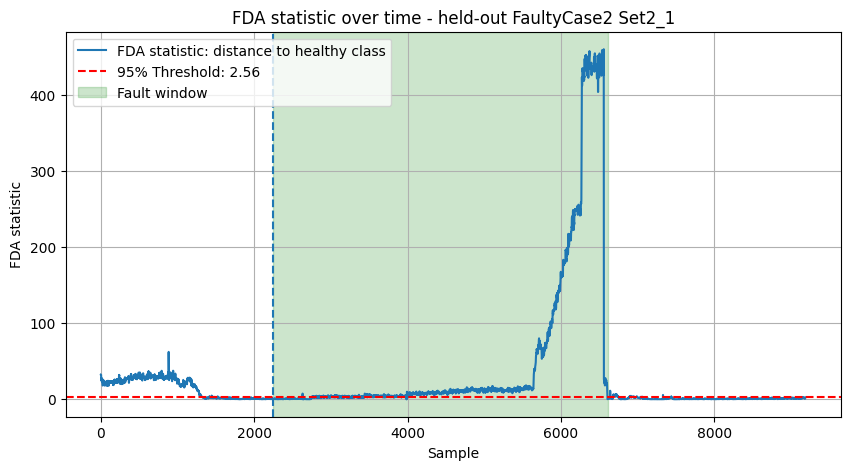

In [35]:

case_name = "FaultyCase2"
set_name = "Set2_1"
windows = se_windows[case_name][set_name]

dataset = FC2sets[set_name]
pred, distances, d_healthy, d_fault, margin = fda_model.predict(dataset)

plt.figure(figsize=(10, 5))
plt.plot(d_healthy, label="FDA statistic: distance to healthy class")
plt.axhline(y=threshold_fda, color="r", linestyle="--", label=f"95% Threshold: {threshold_fda:.2f}")
add_fault_spans(plt.gca(), windows, color="g", label="Fault window")
plt.xlabel("Sample")
plt.ylabel("FDA statistic")
plt.title(f"FDA statistic over time - held-out {case_name} {set_name}")
plt.legend()
plt.grid(True)
plt.show()
